# STA 6933 Final Project Python Conversion
# Created by: Noah Miller

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind
from sklearn.preprocessing import LabelEncoder
import itertools

# Data Cleaning

In [4]:
# Two separate data sets are available and are combined to have one larger dataset
d1 = pd.read_csv("C:/Users/noahm/OneDrive/Documents/Python/STA 6933/CF_PCBA-686978.csv")
d2 = pd.read_csv("C:/Users/noahm/OneDrive/Documents/Python/STA 6933/PCBA-686978.csv")
# Combine two tables
data = pd.concat([d1, d2])

In [5]:
# remove missing values
data = data.dropna()

# remove duplicated
data = data.drop_duplicates()

# EDA

C:\Users\noahm\AppData\Local\Temp\ipykernel_16480\3411920964.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=data, palette='Oranges')


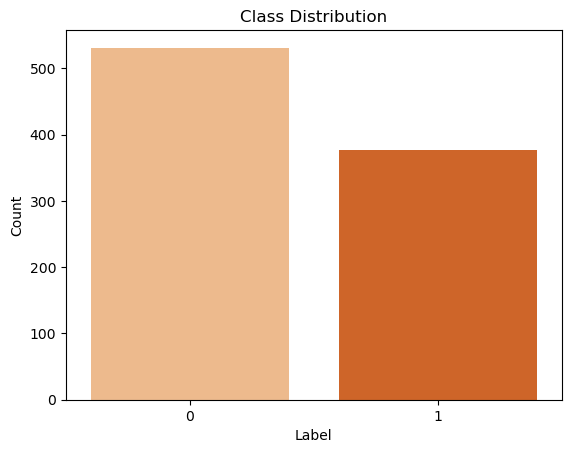

In [7]:
data['Label'] = data['Label'].astype('category')

# Bar plot to show distribution of 'Label'
sns.countplot(x='Label', data=data, palette='Oranges')
plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

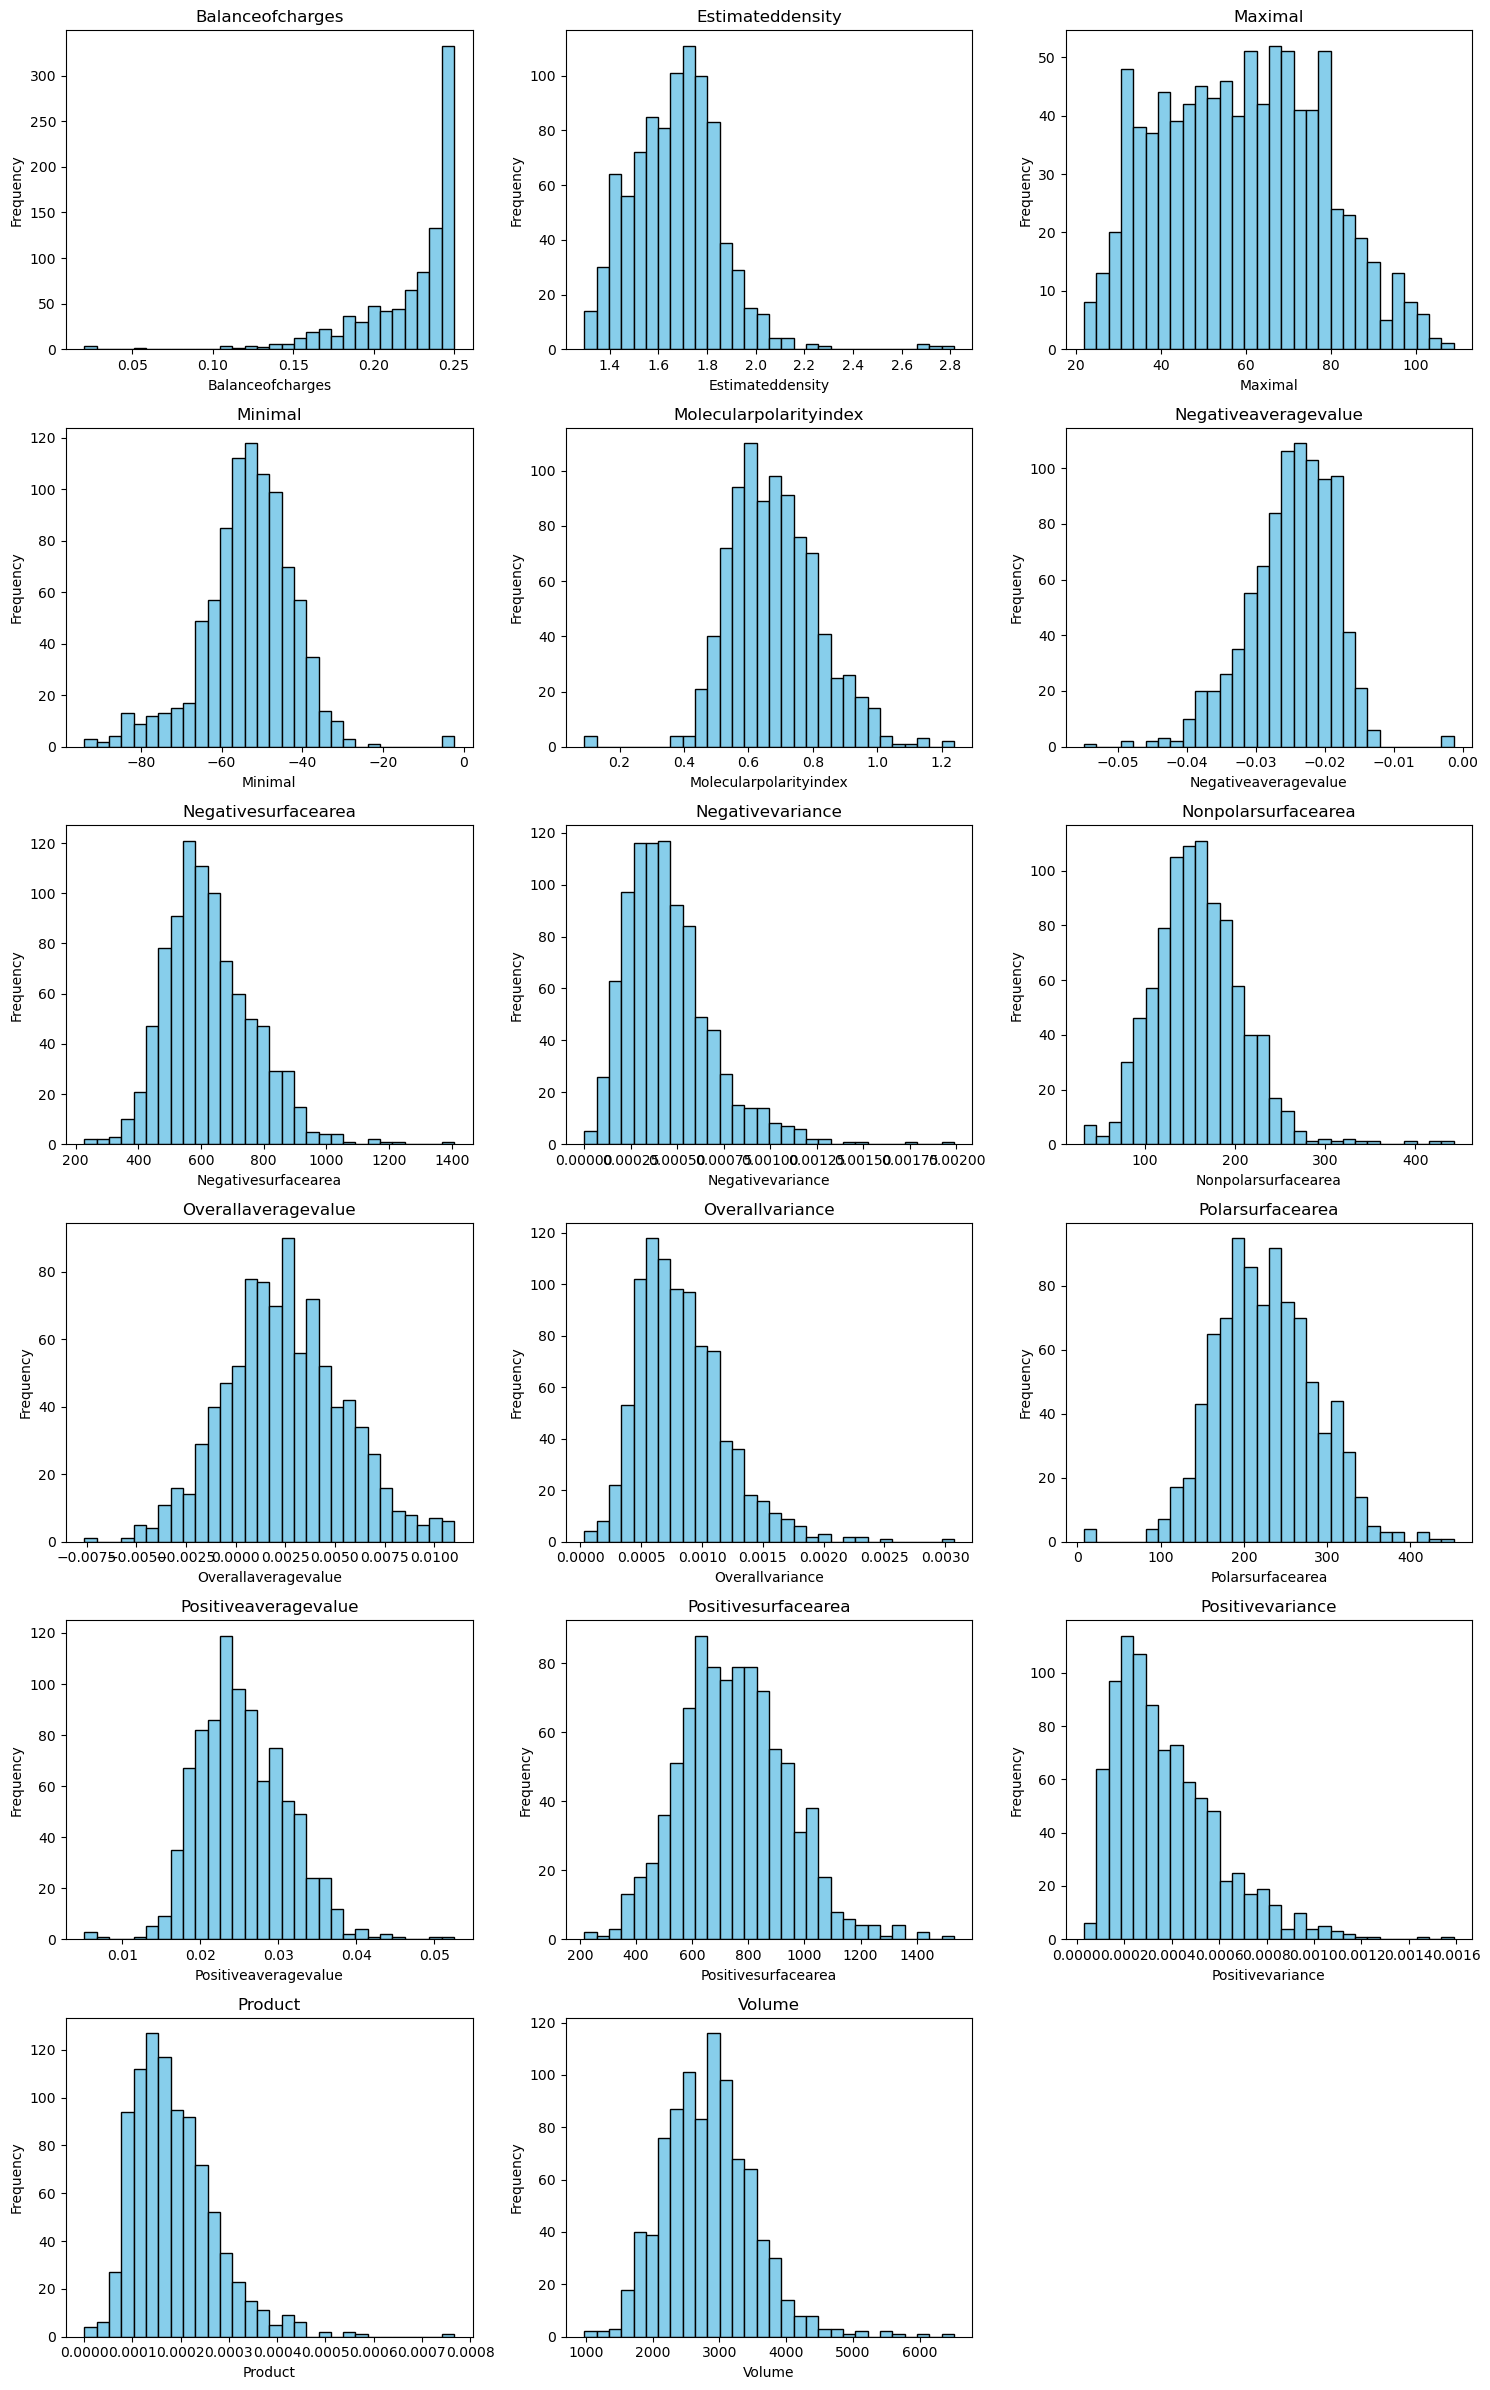

In [8]:
# Get numeric columns (excluding 'Label')
numeric_cols = data.select_dtypes(include=np.number).columns.difference(['Label'])

# Histograms
n = len(numeric_cols)
cols = 3
rows = (n + cols - 1) // cols
plt.figure(figsize=(15, 4 * rows))
for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols, i + 1)
    plt.hist(data[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

C:\Users\noahm\AppData\Local\Temp\ipykernel_16480\3130595648.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y=col, data=data, palette='Set2')
C:\Users\noahm\AppData\Local\Temp\ipykernel_16480\3130595648.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y=col, data=data, palette='Set2')
C:\Users\noahm\AppData\Local\Temp\ipykernel_16480\3130595648.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y=col, data=data, palette='Set2')
C:\Users\noahm\AppData\Local\Temp\ipykernel_16480\3130595648.py:5: Future

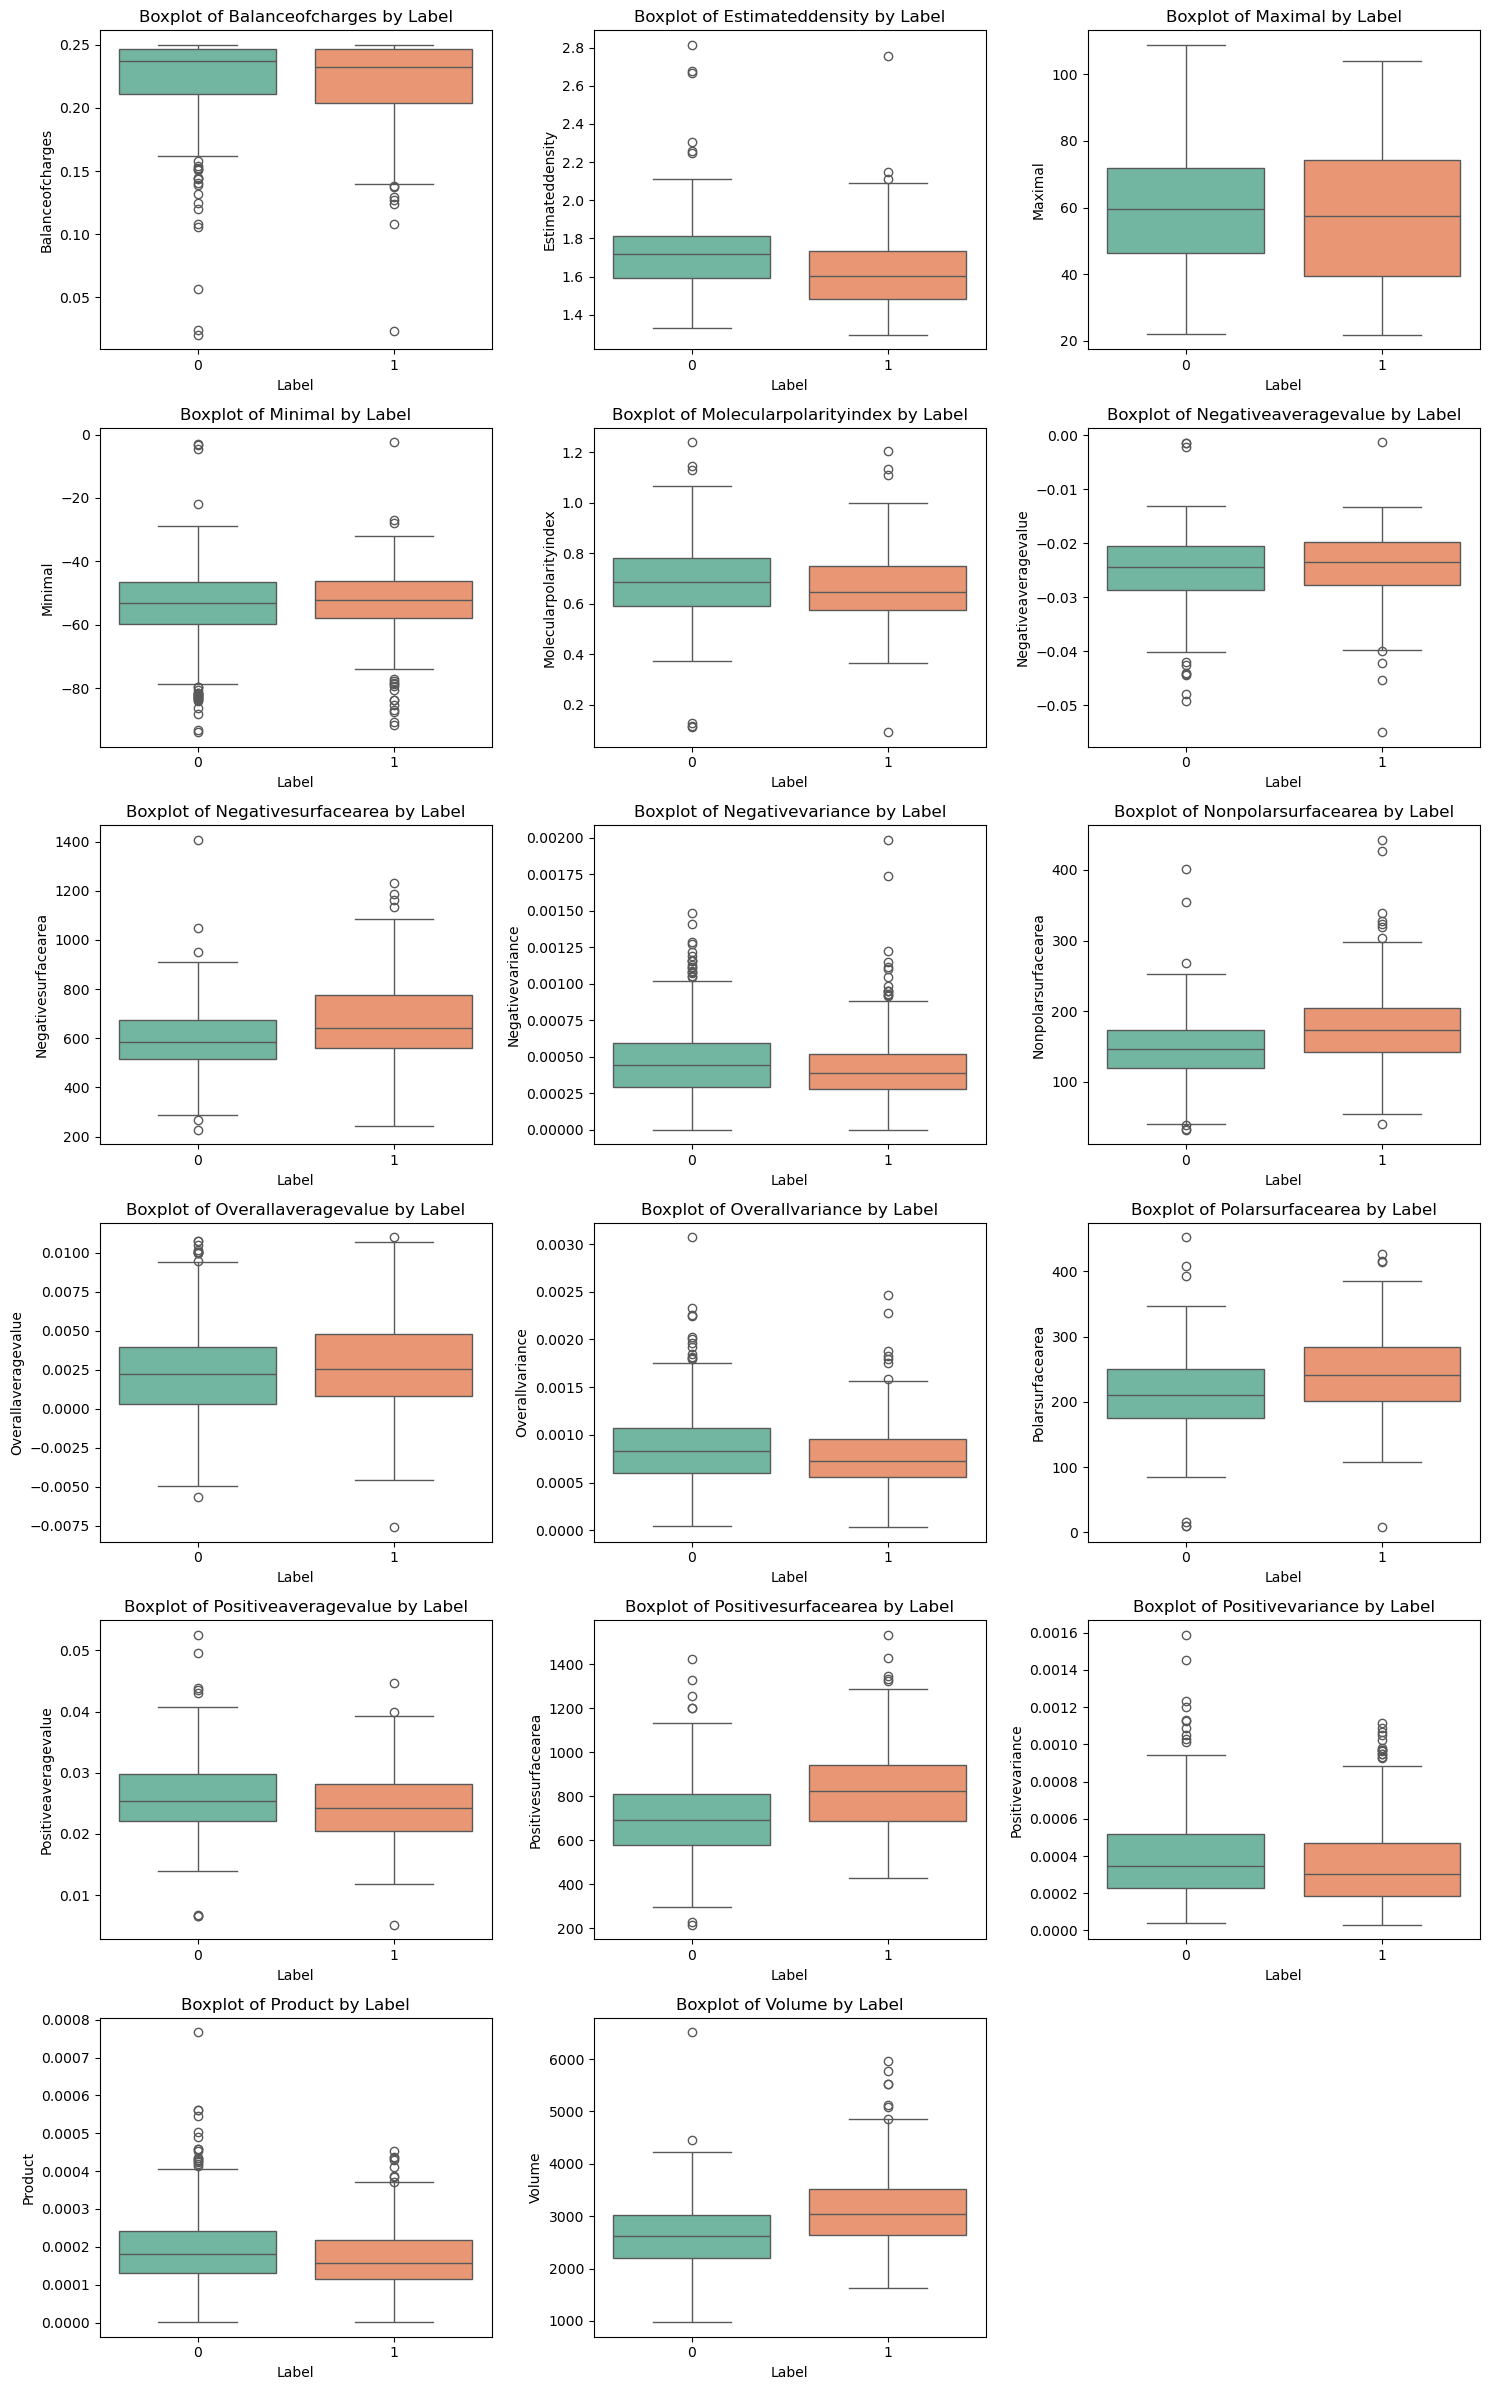

In [9]:
# Boxplots grouped by 'Label'
plt.figure(figsize=(15, 4 * rows))
for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(x='Label', y=col, data=data, palette='Set2')
    plt.title(f'Boxplot of {col} by Label')
plt.tight_layout()
plt.show()

In [10]:
# T-tests
for col in numeric_cols:
    print(f"{col}:")
    groups = [group[col].dropna() for name, group in data.groupby('Label')]
    if len(groups) == 2:
        t_stat, p_val = ttest_ind(groups[0], groups[1])
        print(f"  t-statistic: {t_stat:.4f}, p-value: {p_val:.4e}")
    else:
        print("  Skipped: Not exactly two groups")
    print()

Balanceofcharges:
  t-statistic: 1.8248, p-value: 6.8363e-02

Estimateddensity:
  t-statistic: 8.0646, p-value: 2.3172e-15

Maximal:
  t-statistic: 1.1845, p-value: 2.3654e-01

Minimal:
  t-statistic: -1.7742, p-value: 7.6362e-02

Molecularpolarityindex:
  t-statistic: 2.8617, p-value: 4.3105e-03

Negativeaveragevalue:
  t-statistic: -1.7219, p-value: 8.5433e-02

Negativesurfacearea:
  t-statistic: -7.5605, p-value: 9.8329e-14

Negativevariance:
  t-statistic: 2.9788, p-value: 2.9708e-03

Nonpolarsurfacearea:
  t-statistic: -8.3925, p-value: 1.8155e-16

Overallaveragevalue:
  t-statistic: -2.5072, p-value: 1.2344e-02

Overallvariance:
  t-statistic: 3.5947, p-value: 3.4229e-04

Polarsurfacearea:
  t-statistic: -7.7427, p-value: 2.5972e-14

Positiveaveragevalue:
  t-statistic: 3.3681, p-value: 7.8875e-04

Positivesurfacearea:
  t-statistic: -11.0959, p-value: 6.5016e-27

Positivevariance:
  t-statistic: 2.6657, p-value: 7.8205e-03

Product:
  t-statistic: 4.3258, p-value: 1.6890e-05

Vo

C:\Users\noahm\AppData\Local\Temp\ipykernel_16480\3435810810.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group[col].dropna() for name, group in data.groupby('Label')]


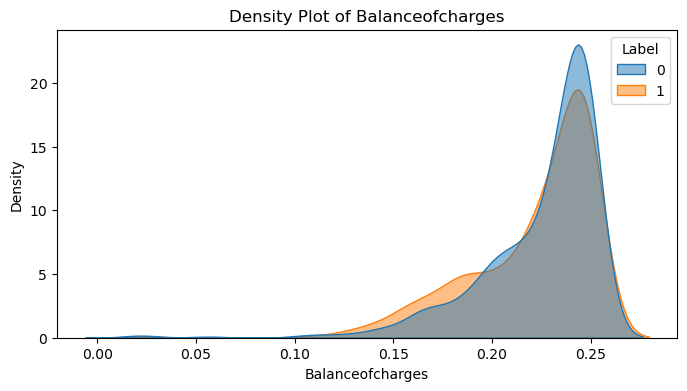

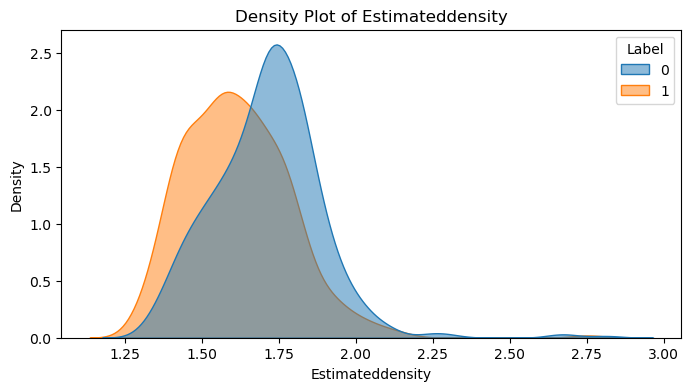

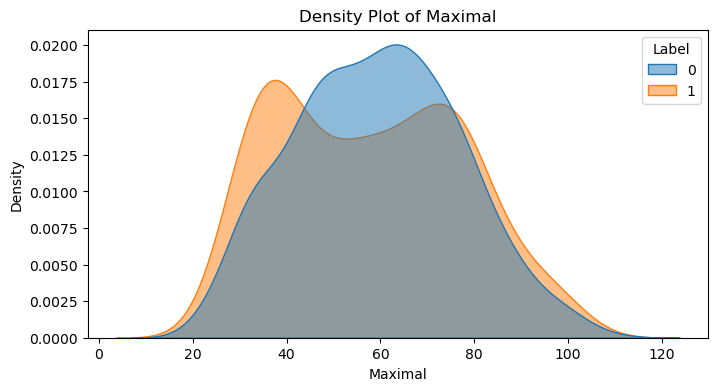

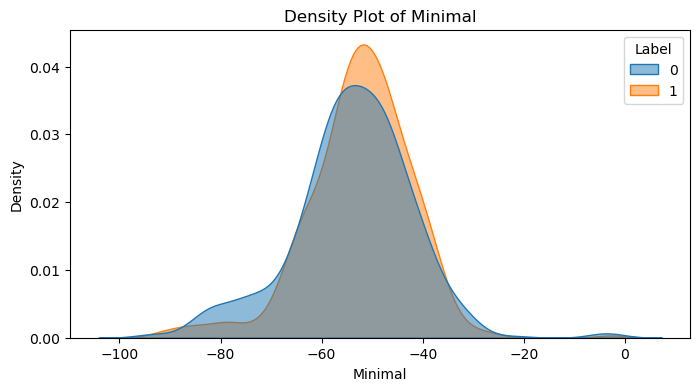

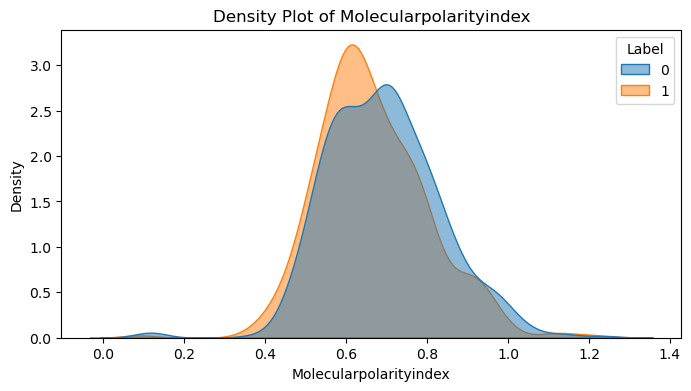

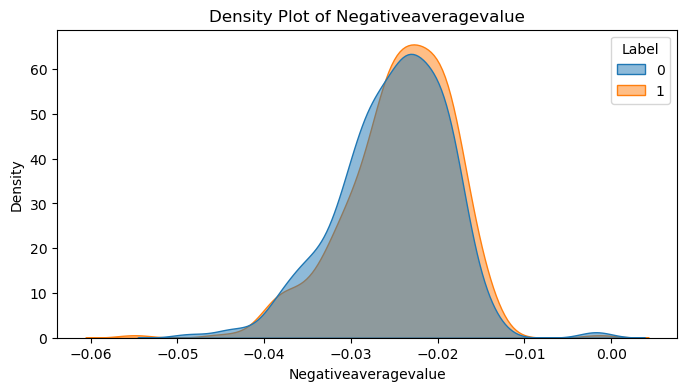

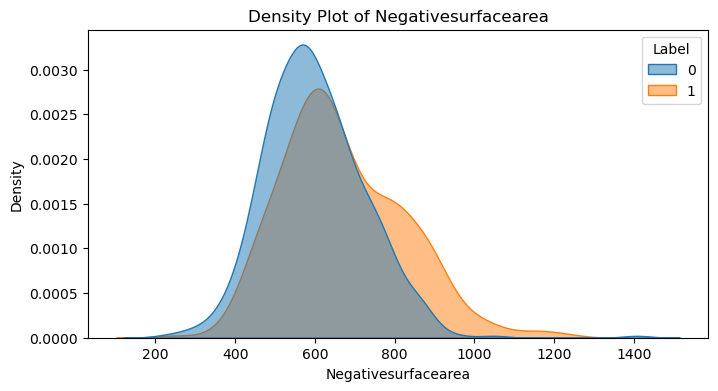

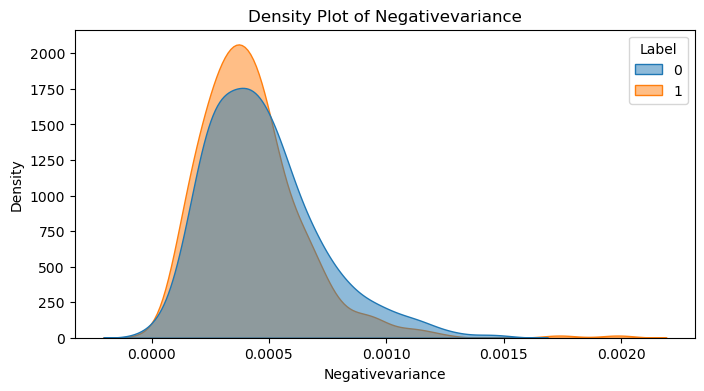

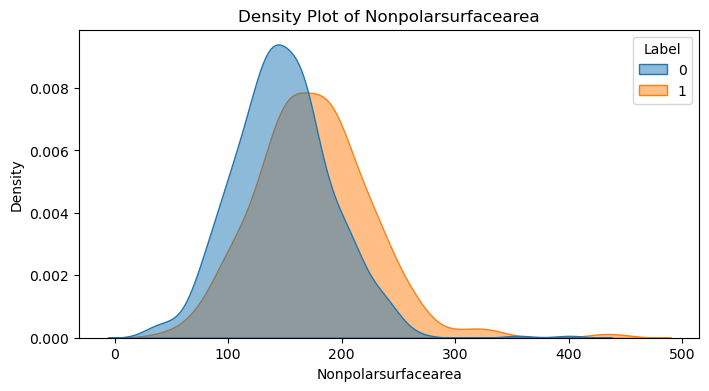

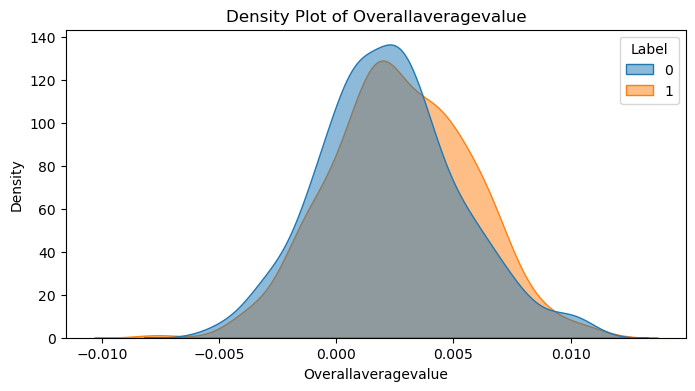

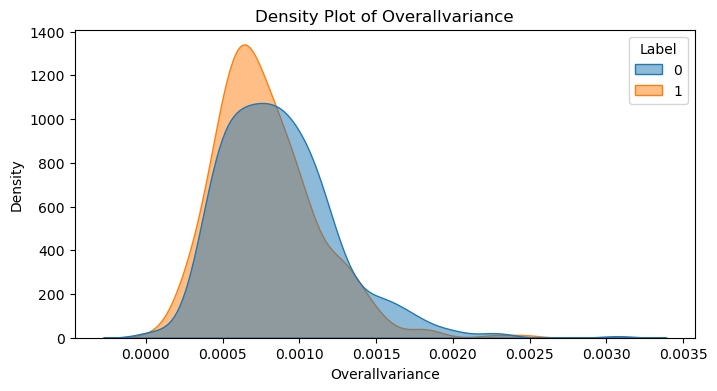

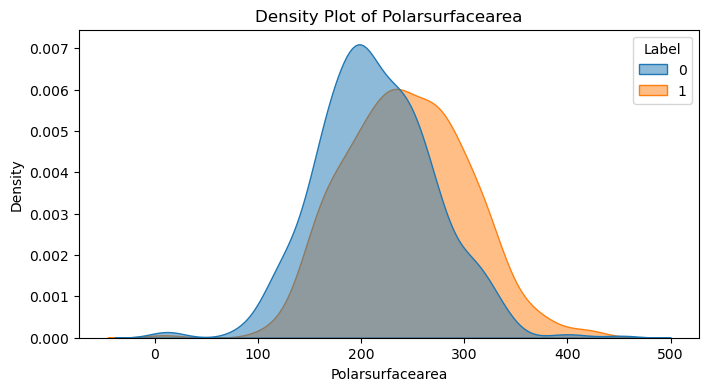

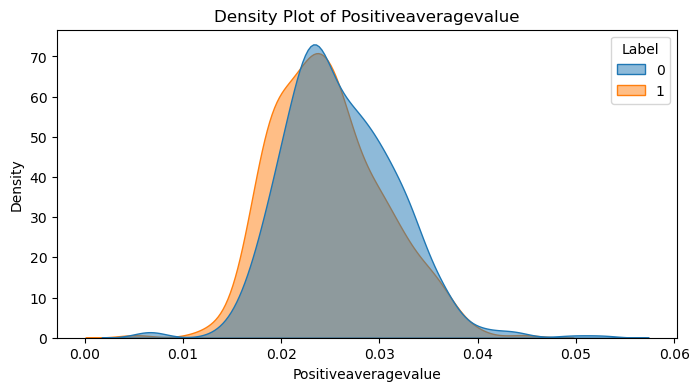

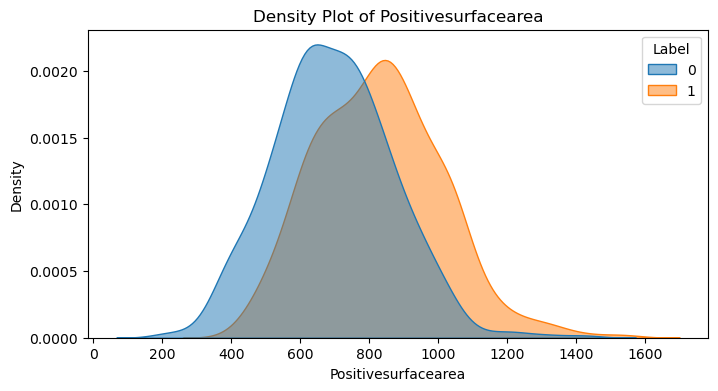

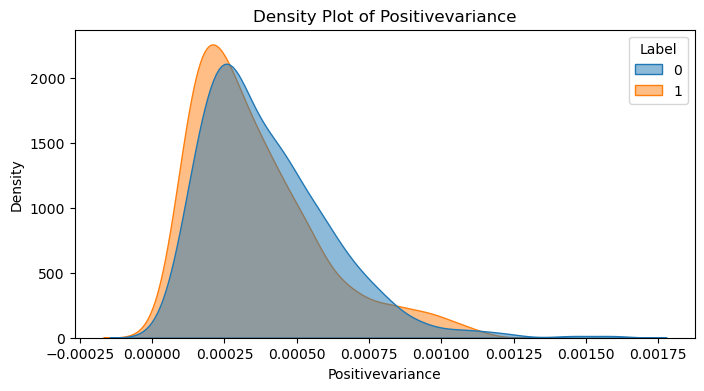

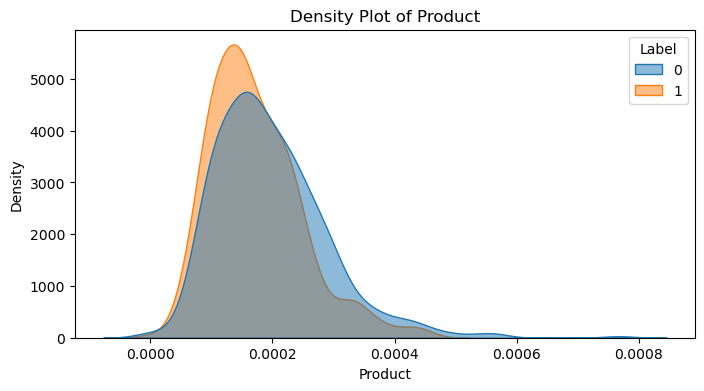

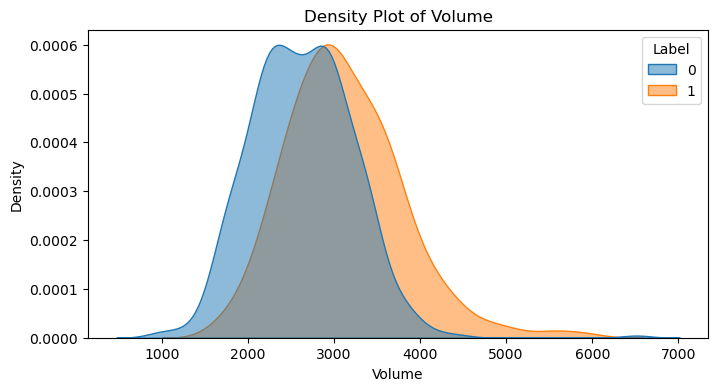

In [11]:
# Density plots
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=data, x=col, hue='Label', fill=True, common_norm=False, alpha=0.5)
    plt.title(f'Density Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.show()

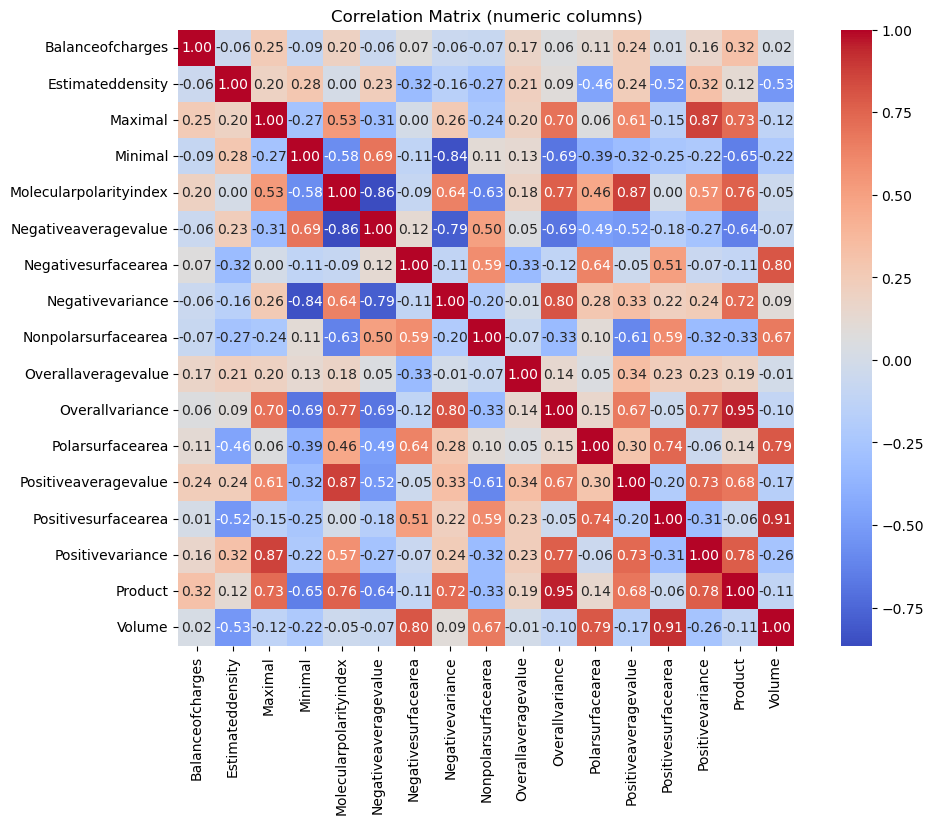

In [12]:
# Correlation plot
corr_matrix = data[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix (numeric columns)")
plt.show()

# Scaling/Normalization & Handle imbalanced Data

In [14]:
# Extract only numeric predictors (excluding Label)
y = data['Label']
x_scaled = data.drop(columns='Label', errors='ignore').select_dtypes(include='number')

# Normalize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = pd.DataFrame(scaler.fit_transform(x_scaled), columns=x_scaled.columns)

In [15]:
from imblearn.over_sampling import ADASYN

# Initialize and fit ADASYN
adas = ADASYN(n_neighbors=5, random_state=42)
X_resampled, y_resampled = adas.fit_resample(x_scaled, y)

In [16]:
# Combine into one DataFrame
balanced_data = pd.DataFrame(X_resampled, columns=x_scaled.columns)
balanced_data['class'] = y_resampled

# View class distribution
print(balanced_data['class'].value_counts())

class
0    531
1    528
Name: count, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
random_state = 123

# Split into training and testing sets (70% train, 30% test)
pfas_train, pfas_test = train_test_split(balanced_data, test_size=0.3, random_state=random_state, shuffle=True)

# Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, matthews_corrcoef

# Convert class to numeric
pfas_train['class'] = pfas_train['class'].astype(int)
pfas_test['class'] = pfas_test['class'].astype(int)

# Logistic Regression Model (equivalent to glm with binomial)
X_train = pfas_train.drop(columns='class')
y_train = pfas_train['class']

model = LogisticRegression(solver='liblinear')  # 'liblinear' is good for small binary datasets
model.fit(X_train, y_train)

# Summary (coefficients)
print("Logistic Regression Coefficients:")
for feature, coef in zip(X_train.columns, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {model.intercept_[0]:.4f}")

Logistic Regression Coefficients:
Volume: 0.9022
Estimateddensity: -0.2794
Minimal: 0.2513
Maximal: 0.2253
Positivesurfacearea: -0.0252
Negativesurfacearea: -0.0586
Overallaveragevalue: 0.2142
Positiveaveragevalue: -0.4435
Negativeaveragevalue: -0.0097
Overallvariance: 0.2384
Positivevariance: 0.4171
Negativevariance: -0.0257
Balanceofcharges: -0.0050
Product: -0.7762
Molecularpolarityindex: 0.4446
Nonpolarsurfacearea: 0.0577
Polarsurfacearea: -0.1103
Intercept: -0.0718


In [20]:
# Make predictions (probabilities)
X_test = pfas_test.drop(columns='class')
y_test = pfas_test['class']
pred_probs = model.predict_proba(X_test)[:, 1]

# Convert to binary predictions using threshold = 0.5
pred_binary = (pred_probs > 0.5).astype(int)

In [21]:
# Confusion matrix
cm = confusion_matrix(y_test, pred_binary)
print("Confusion Matrix:")
print(cm)

# F1-score
f1 = f1_score(y_test, pred_binary)
print(f"F1-score: {f1:.4f}")

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, pred_binary)
print(f"MCC: {mcc:.4f}")

Confusion Matrix:
[[ 97  51]
 [ 57 113]]
F1-score: 0.6766
MCC: 0.3195


In [22]:
precision = precision_score(y_test, pred_binary)
recall = recall_score(y_test, pred_binary)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Precision: 0.6890
Recall: 0.6647


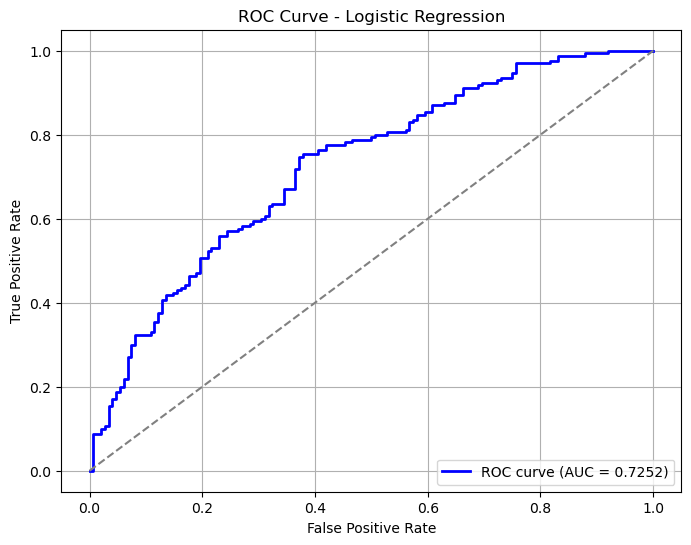

AUC-ROC: 0.7252


In [23]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, pred_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"AUC-ROC: {roc_auc:.4f}")

In [24]:
# Selected predictors
selected_features = ['Estimateddensity', 'Overallaveragevalue', 'Positiveaveragevalue', 'Molecularpolarityindex']

# Train model with selected features
X_train_sel = pfas_train[selected_features]
X_test_sel = pfas_test[selected_features]

model2 = LogisticRegression(solver='liblinear')
model2.fit(X_train_sel, y_train)

# Print summary (coefficients)
print("\nLogistic Regression (Selected Predictors) Coefficients:")
for feature, coef in zip(selected_features, model2.coef_[0]):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {model2.intercept_[0]:.4f}")


Logistic Regression (Selected Predictors) Coefficients:
Estimateddensity: -0.5844
Overallaveragevalue: 0.2798
Positiveaveragevalue: 0.0772
Molecularpolarityindex: -0.3045
Intercept: -0.0723


In [25]:
# Predict probabilities on test data
pred_probs_sel = model2.predict_proba(X_test_sel)[:, 1]

# Convert to binary with threshold 0.5
pred_binary_sel = (pred_probs_sel > 0.5).astype(int)

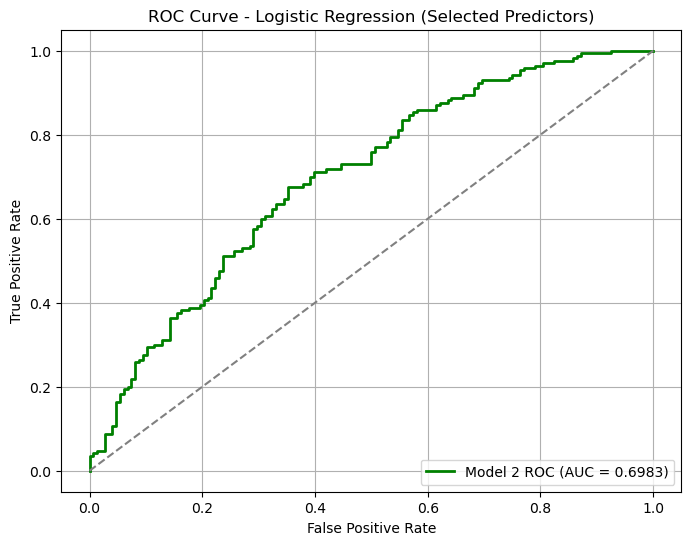

AUC-ROC (Model 2): 0.6983


In [26]:
# ROC and AUC for model2
fpr2, tpr2, _ = roc_curve(y_test, pred_probs_sel)
roc_auc2 = auc(fpr2, tpr2)

plt.figure(figsize=(8, 6))
plt.plot(fpr2, tpr2, color='green', lw=2, label=f'Model 2 ROC (AUC = {roc_auc2:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (Selected Predictors)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"AUC-ROC (Model 2): {roc_auc2:.4f}")

In [27]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, matthews_corrcoef

# Confusion Matrix
cm = confusion_matrix(y_test, pred_binary_sel)
print("Confusion Matrix:")
print(cm)

# MCC (Matthews Correlation Coefficient) calculation
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)
mcc = (TP * TN - FP * FN) / np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))

print(f"F1-score:  {f1:.4f}")
print(f"MCC:       {mcc:.4f}")

Confusion Matrix:
[[ 98  50]
 [ 62 108]]
F1-score:  0.6585
MCC:       0.2967


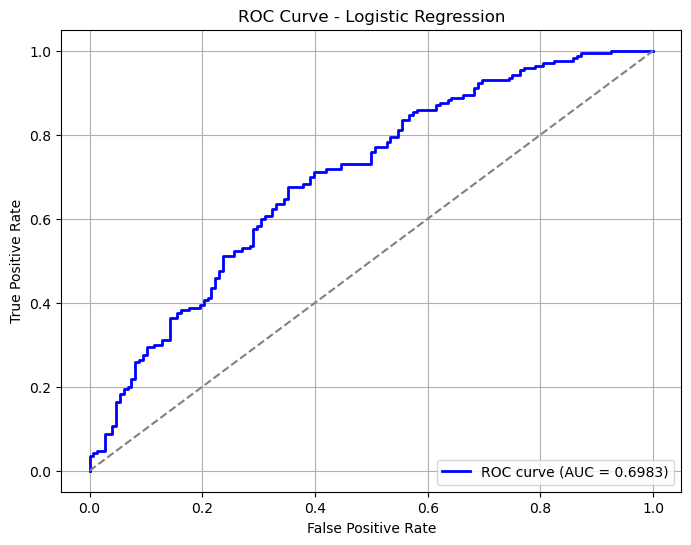

AUC-ROC: 0.6983


In [28]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, pred_probs_sel)
auc_value = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc_value:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC-ROC: {auc_value:.4f}")

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures

# Select and transform predictors
poly_features = ['Positivevariance', 'Maximal', 'Overallvariance']
other_features = [
    'Volume', 'Estimateddensity', 'Minimal', 'Overallaveragevalue',
    'Positiveaveragevalue', 'Balanceofcharges', 'Product', 'Molecularpolarityindex'
]

# Combine selected features
X_train_base = pfas_train[poly_features + other_features].copy()
X_test_base = pfas_test[poly_features + other_features].copy()

# Apply polynomial transformation to selected columns
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(pfas_train[poly_features])
X_test_poly = poly.transform(pfas_test[poly_features])

# Create DataFrames for poly features with proper column names
poly_feature_names = poly.get_feature_names_out(poly_features)
X_train_poly_df = pd.DataFrame(X_train_poly, columns=poly_feature_names, index=pfas_train.index)
X_test_poly_df = pd.DataFrame(X_test_poly, columns=poly_feature_names, index=pfas_test.index)

# Concatenate polynomial and other features
X_train_final = pd.concat([X_train_poly_df, pfas_train[other_features]], axis=1)
X_test_final = pd.concat([X_test_poly_df, pfas_test[other_features]], axis=1)

# Target variable
y_train = pfas_train['class']
y_test = pfas_test['class']

# Fit logistic regression
model3 = LogisticRegression(solver='liblinear', max_iter=1000)
model3.fit(X_train_final, y_train)

# Display coefficients (optional)
print("Logistic Regression with Polynomial Terms - Coefficients:")
for feature, coef in zip(X_train_final.columns, model3.coef_[0]):
    print(f"{feature}: {coef:.4f}")

Logistic Regression with Polynomial Terms - Coefficients:
Positivevariance: 0.0851
Maximal: 0.3561
Overallvariance: -0.3252
Positivevariance^2: 0.0215
Positivevariance Maximal: 0.6037
Positivevariance Overallvariance: -0.4567
Maximal^2: 0.0142
Maximal Overallvariance: -0.2819
Overallvariance^2: 0.2715
Volume: 0.7465
Estimateddensity: -0.2916
Minimal: 0.2924
Overallaveragevalue: 0.2109
Positiveaveragevalue: -0.3656
Balanceofcharges: 0.0438
Product: -0.0885
Molecularpolarityindex: 0.2508


In [30]:
# Predict probabilities
lg_preds = model3.predict_proba(X_test_final)[:, 1]

# Convert to binary predictions using 0.5 threshold
pred_binary = (lg_preds > 0.5).astype(int)

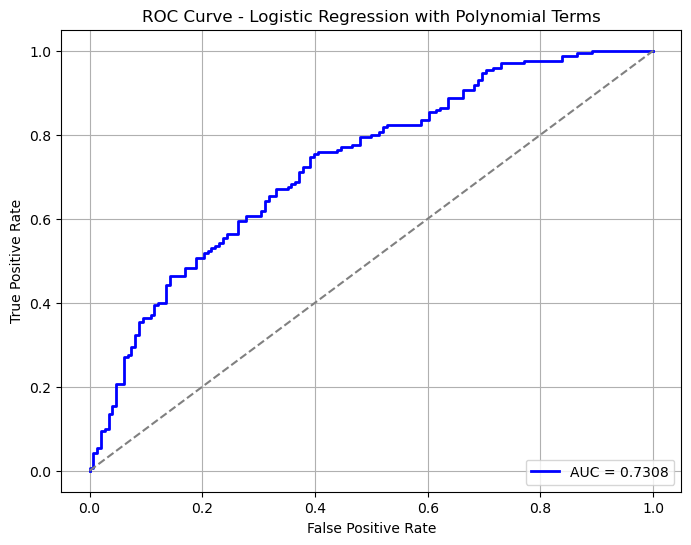

AUC-ROC: 0.7308


In [31]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, lg_preds)
auc_value = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {auc_value:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression with Polynomial Terms')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC-ROC: {auc_value:.4f}")

In [32]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, matthews_corrcoef

# Confusion matrix
cm = confusion_matrix(y_test, pred_binary)
print("Confusion Matrix:")
print(cm)

# Manually extract values
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Manual metrics
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)
mcc = (TP * TN - FP * FN) / np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"MCC:       {mcc:.4f}")

Confusion Matrix:
[[101  47]
 [ 61 109]]
Precision: 0.6987
Recall:    0.6412
F1-score:  0.6687
MCC:       0.3229


The AUC-ROC value for this logistic regression model is the highest of the models, which makes it the best one to use.

# Forward Stepwise Selection

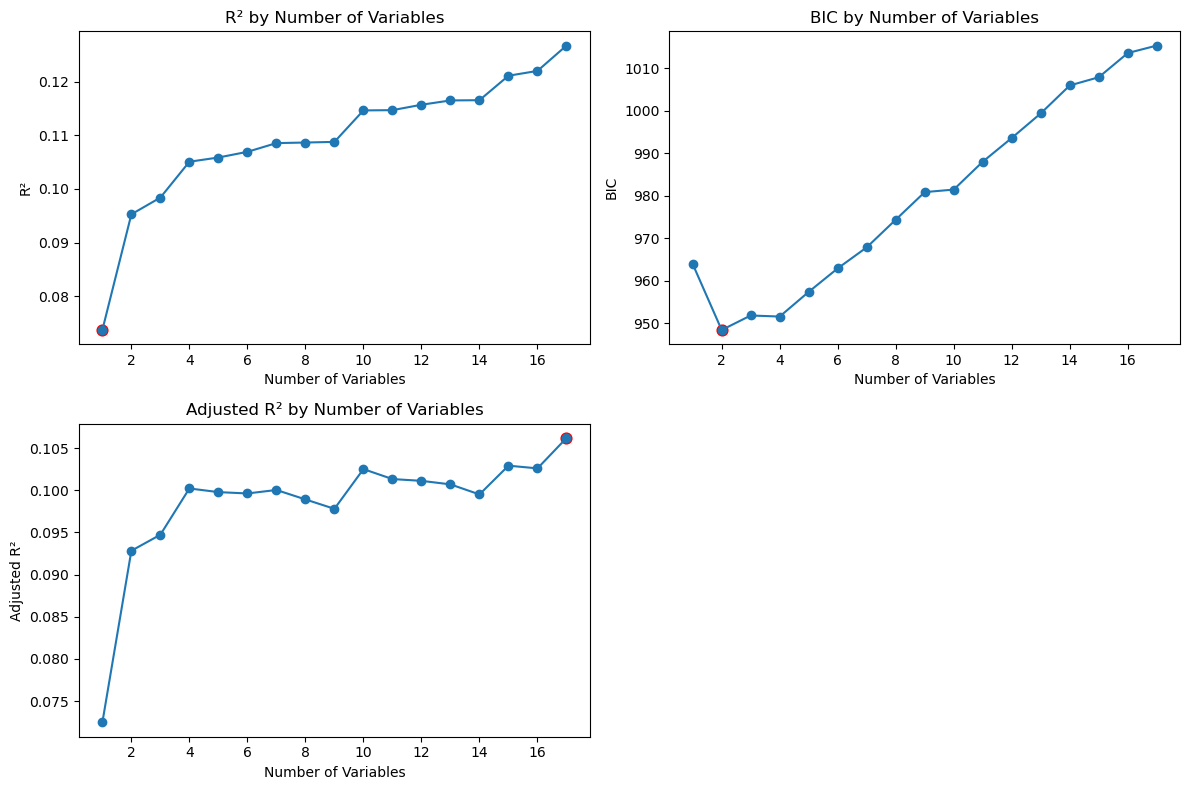

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# ---- Setup ----
# pfas_train: your training DataFrame
X = pfas_train.drop(columns='class')
y = pfas_train['class']

# Logistic regression model
logreg = LogisticRegression(max_iter=1000, solver='liblinear')

# Forward stepwise selection
max_features = X.shape[1]

sfs = SFS(logreg,
          k_features=max_features,
          forward=True,
          floating=False,
          scoring='accuracy',
          cv=5,
          n_jobs=-1)

sfs = sfs.fit(X.values, y.values)

# ---- Collect R², Adjusted R², and BIC ----
n = len(y)
rsq_list = []
adjr2_list = []
bic_list = []

for k in range(1, max_features + 1):
    subset_idx = list(sfs.subsets_[k]['feature_idx'])
    X_k = X.iloc[:, subset_idx]
    logreg.fit(X_k, y)
    
    # Predicted probabilities for log-loss
    prob = logreg.predict_proba(X_k)[:, 1]
    ll = -log_loss(y, prob, normalize=False)
    
    # Null model log-likelihood
    y_mean_prob = np.full_like(y, y.mean(), dtype=np.float64)
    null_ll = -log_loss(y, y_mean_prob, normalize=False)
    
    # Pseudo R² (McFadden-like)
    rsq = 1 - ll / null_ll
    rsq_list.append(rsq)
    
    # Adjusted R²
    k_params = k + 1  # +1 for intercept
    adjr2 = 1 - (1 - rsq) * (n - 1) / (n - k_params)
    adjr2_list.append(adjr2)
    
    # BIC
    bic = np.log(n) * k_params - 2 * ll
    bic_list.append(bic)

# ---- Plotting (replicates R's par(mfrow=c(2,2)) style) ----
plt.figure(figsize=(12, 8))

# R²
plt.subplot(2, 2, 1)
plt.plot(range(1, max_features + 1), rsq_list, marker='o')
plt.xlabel("Number of Variables")
plt.ylabel("R²")
plt.title("R² by Number of Variables")
min_rsq_idx = np.argmin(rsq_list)
plt.scatter(min_rsq_idx + 1, rsq_list[min_rsq_idx], color='red', s=60)

# BIC
plt.subplot(2, 2, 2)
plt.plot(range(1, max_features + 1), bic_list, marker='o')
plt.xlabel("Number of Variables")
plt.ylabel("BIC")
plt.title("BIC by Number of Variables")
min_bic_idx = np.argmin(bic_list)
plt.scatter(min_bic_idx + 1, bic_list[min_bic_idx], color='red', s=60)

# Adjusted R²
plt.subplot(2, 2, 3)
plt.plot(range(1, max_features + 1), adjr2_list, marker='o')
plt.xlabel("Number of Variables")
plt.ylabel("Adjusted R²")
plt.title("Adjusted R² by Number of Variables")
max_adjr2_idx = np.argmax(adjr2_list)
plt.scatter(max_adjr2_idx + 1, adjr2_list[max_adjr2_idx], color='red', s=60)

plt.tight_layout()
plt.show()

In [36]:
# Get selected features for 4-variable model
selected_idx_4 = list(sfs.subsets_[4]['feature_idx'])
selected_features_4 = X.columns[selected_idx_4]

# Fit final model
X_4 = X[selected_features_4]
logreg.fit(X_4, y)

# Show coefficients
coef_df = pd.DataFrame({
    'Feature': selected_features_4,
    'Coefficient': logreg.coef_[0]
})
print("Coefficients for 4-variable model:")
print(coef_df)

Coefficients for 4-variable model:
               Feature  Coefficient
0  Positivesurfacearea     0.935612
1      Overallvariance     0.367226
2     Negativevariance    -0.702135
3     Balanceofcharges    -0.175876


# XGBoost

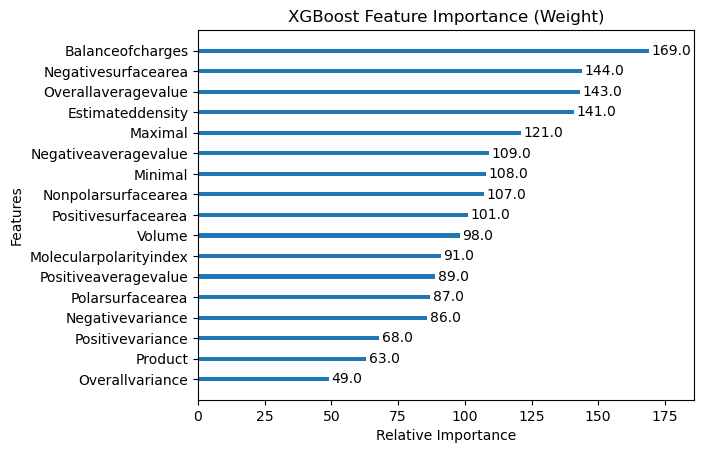

In [67]:
import xgboost as xgb
from sklearn.metrics import confusion_matrix, f1_score, matthews_corrcoef, roc_auc_score, roc_curve

# Prepare the training data
X_train = pfas_train.drop(columns='class').apply(pd.to_numeric)
y_train = pfas_train['class'].astype(int)

X_test = pfas_test.drop(columns='class').apply(pd.to_numeric)
y_test = pfas_test['class'].astype(int)

dtrain = xgb.DMatrix(data=X_train, label=y_train)
dtest = xgb.DMatrix(data=X_test, label=y_test)

# Train basic XGBoost model
xg_basic = xgb.train(
    params={"objective": "binary:logistic"},
    dtrain=dtrain,
    num_boost_round=100,
    verbose_eval=False
)

# Feature importance
xgb.plot_importance(xg_basic, importance_type='weight', max_num_features=20, grid=False)
plt.title("XGBoost Feature Importance (Weight)")
plt.xlabel("Relative Importance")
plt.show()

In [73]:
# Set parameters
params = {
    'objective': 'binary:logistic',
    'eta': 0.01,
    'max_depth': 25,
    'colsample_bytree': 0.7,
    'gamma': 0,
    'min_child_weight': 1,
    'nthread': 2,
    'eval_metric': 'error'
}

# Train model with more rounds
xg_model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=300,
    verbose_eval=False
)

# Predict probabilities
xg_preds = xg_model.predict(dtest)

# Convert to binary predictions
pred_binary = (xg_preds > 0.5).astype(int)

In [75]:
# Confusion matrix
cm = confusion_matrix(y_test, pred_binary)
print("Confusion Matrix:")
print(cm)

# Manual extraction (like in R)
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# Precision, Recall, F1
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * precision * recall / (precision + recall)
mcc = (TP * TN - FP * FN) / np.sqrt((TP + FP)*(TP + FN)*(TN + FP)*(TN + FN))

print(f"F1-score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

Confusion Matrix:
[[106  42]
 [ 42 128]]
F1-score: 0.7529
MCC: 0.4692


ROC AUC: 0.8041


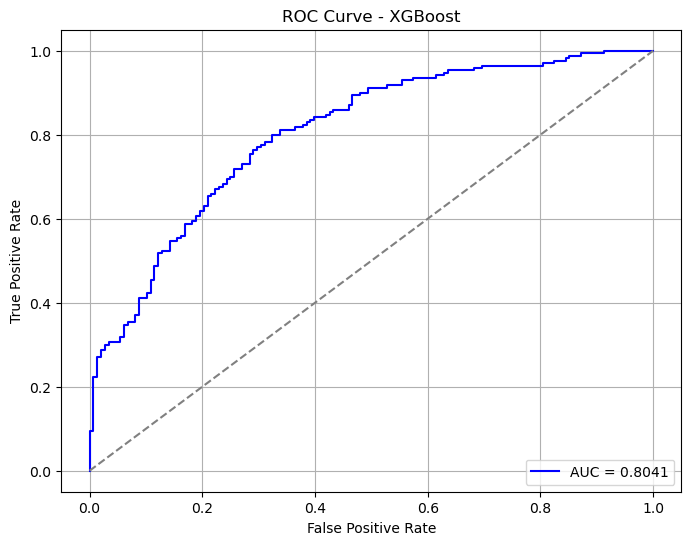

In [77]:
# AUC
auc_value = roc_auc_score(y_test, xg_preds)
print(f"ROC AUC: {auc_value:.4f}")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, xg_preds)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_value:.4f}', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Random Forest

C:\Users\noahm\AppData\Local\Temp\ipykernel_16480\1048757624.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, y='Feature', x='Importance', palette='viridis')


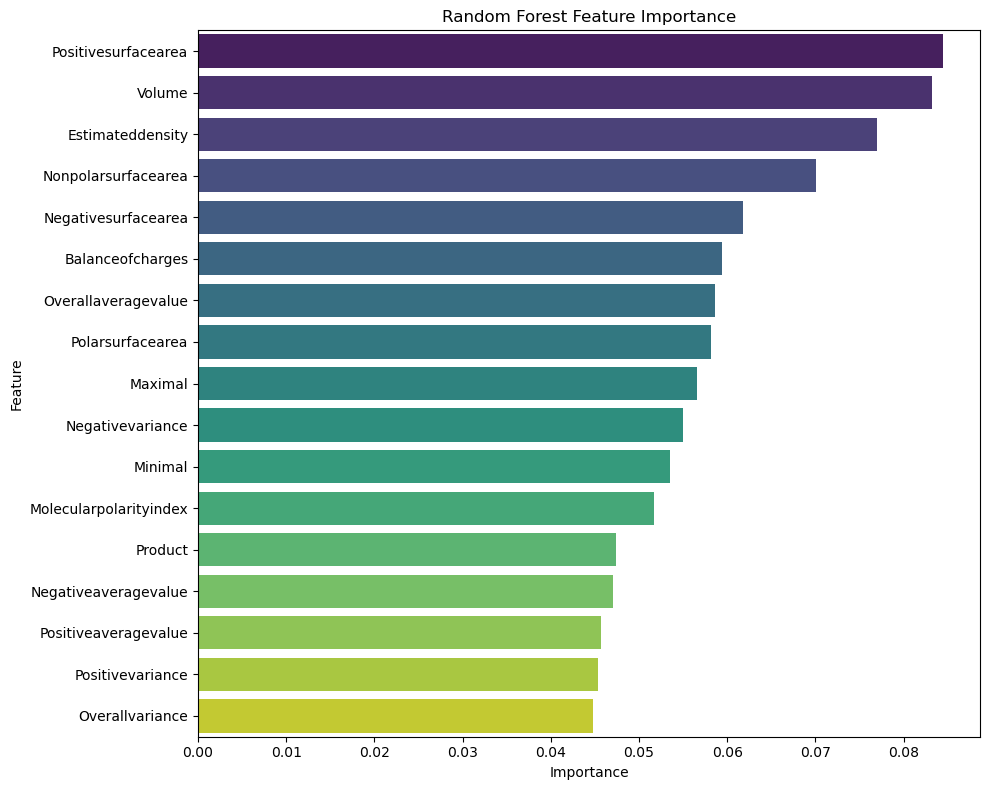

In [80]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=5000, random_state=42)
rf_model.fit(X_train, y_train)

# Feature importances
importances = rf_model.feature_importances_
features = X_train.columns

# Create DataFrame for importance
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, y='Feature', x='Importance', palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Random Forest w/ tuning hyperparameters

In [82]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    min_samples_split=2,  # Note: scikit-learn min is 2, not 1
    max_features='sqrt',  # sqrt(num_features), like mtry in R
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, min_samples_leaf=5, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [84]:
# Predict class labels
pred_binary = rf_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, pred_binary)
print("Confusion Matrix:")
print(cm)

# Extract components
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# F1-score
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)
mcc = (TP * TN - FP * FN) / np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))

print(f"F1-score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

Confusion Matrix:
[[108  40]
 [ 50 120]]
F1-score: 0.7273
MCC: 0.4346


ROC AUC: 0.7984


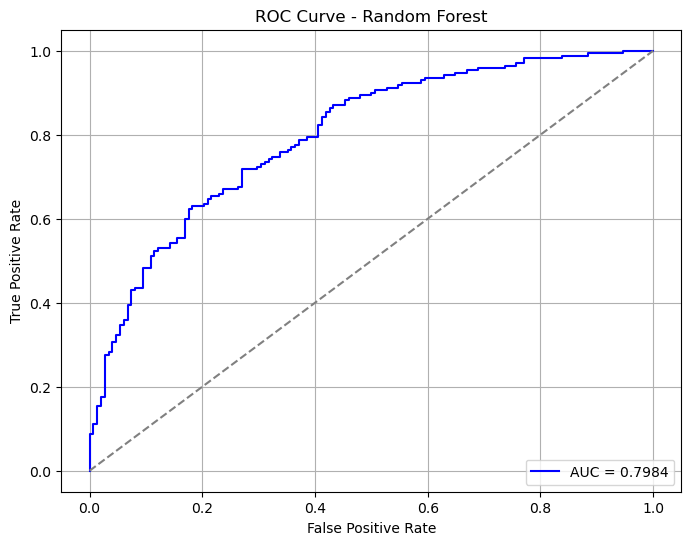

In [86]:
# Predict class probabilities
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# ROC AUC
auc_value = roc_auc_score(y_test, rf_probs)
print(f"ROC AUC: {auc_value:.4f}")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc_value:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# SVM

In [88]:
from sklearn.svm import SVC

# Train SVM with RBF kernel
svm_model = SVC(
    kernel='rbf',
    C=100,             # cost = 100
    gamma=0.01,        # sigma = 0.01 → gamma = 1 / (2*sigma^2)
    probability=True,
    random_state=42
)
svm_model.fit(X_train, y_train)

SVC(C=100, gamma=0.01, probability=True, random_state=42)

In [90]:
# Class predictions
pred_binary = svm_model.predict(X_test)

# Probability predictions for the positive class
pred_svm_probs = svm_model.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, pred_binary)
print("Confusion Matrix:")
print(cm)

# Extract values
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# MCC
mcc = (TP * TN - FP * FN) / np.sqrt((TP + FP)*(TP + FN)*(TN + FP)*(TN + FN))
print(f"MCC: {mcc:.4f}")

# F1-score
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)
print(f"F1-score: {f1:.4f}")

Confusion Matrix:
[[101  47]
 [ 64 106]]
MCC: 0.3054
F1-score: 0.6563


ROC AUC: 0.7138


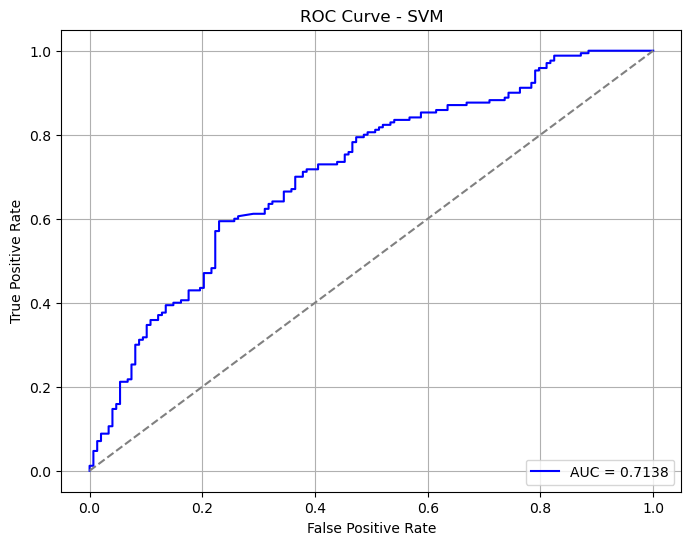

In [92]:
# ROC AUC
auc_value = roc_auc_score(y_test, pred_svm_probs)
print(f"ROC AUC: {auc_value:.4f}")

# Plot ROC
fpr, tpr, _ = roc_curve(y_test, pred_svm_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_value:.4f}', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Light GBM

In [94]:
import lightgbm as lgb

# Convert to LightGBM Dataset
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# LightGBM parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.01,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'max_depth': 15,
    'min_data_in_leaf': 20
}

# Train the model
evals_result = {}

lt_gbm_model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[test_data],
    valid_names=['test'],
    callbacks=[
        lgb.record_evaluation(evals_result),
        lgb.log_evaluation(period=0)  # Set to 0 to silence logging
    ]
)

[LightGBM] [Info] Number of positive: 358, number of negative: 383
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001305 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4204
[LightGBM] [Info] Number of data points in the train set: 741, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.483131 -> initscore=-0.067502
[LightGBM] [Info] Start training from score -0.067502
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [95]:
# Predict probabilities on test set
lt_gbm_pred = lt_gbm_model.predict(X_test)

# Binary predictions (threshold = 0.5)
y_pred_binary = (lt_gbm_pred > 0.5).astype(int)

In [98]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_binary)
print("Confusion Matrix:")
print(cm)

# Extract values
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

# F1-score
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)
print(f"F1-score: {f1:.4f}")

# Matthews Correlation Coefficient
mcc = (TP * TN - FP * FN) / np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
print(f"MCC: {mcc:.4f}")

Confusion Matrix:
[[108  40]
 [ 48 122]]
F1-score: 0.7349
MCC: 0.4464


ROC AUC: 0.8188


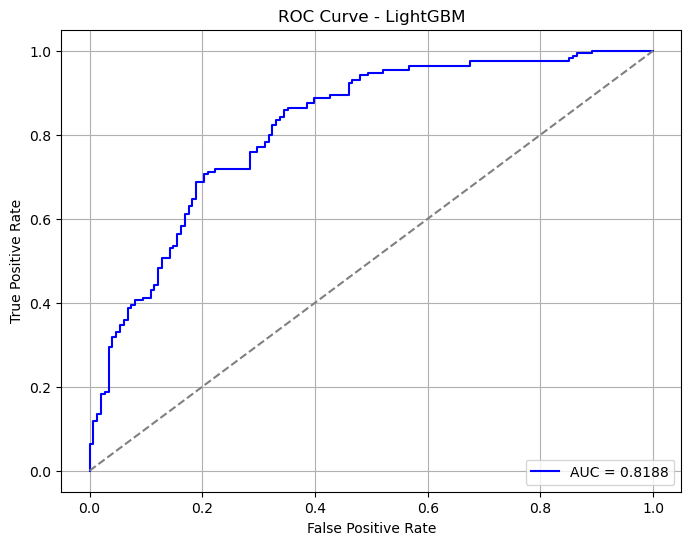

In [100]:
# ROC AUC
auc_value = roc_auc_score(y_test, lt_gbm_pred)
print(f"ROC AUC: {auc_value:.4f}")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, lt_gbm_pred)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_value:.4f}', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# GAM Model

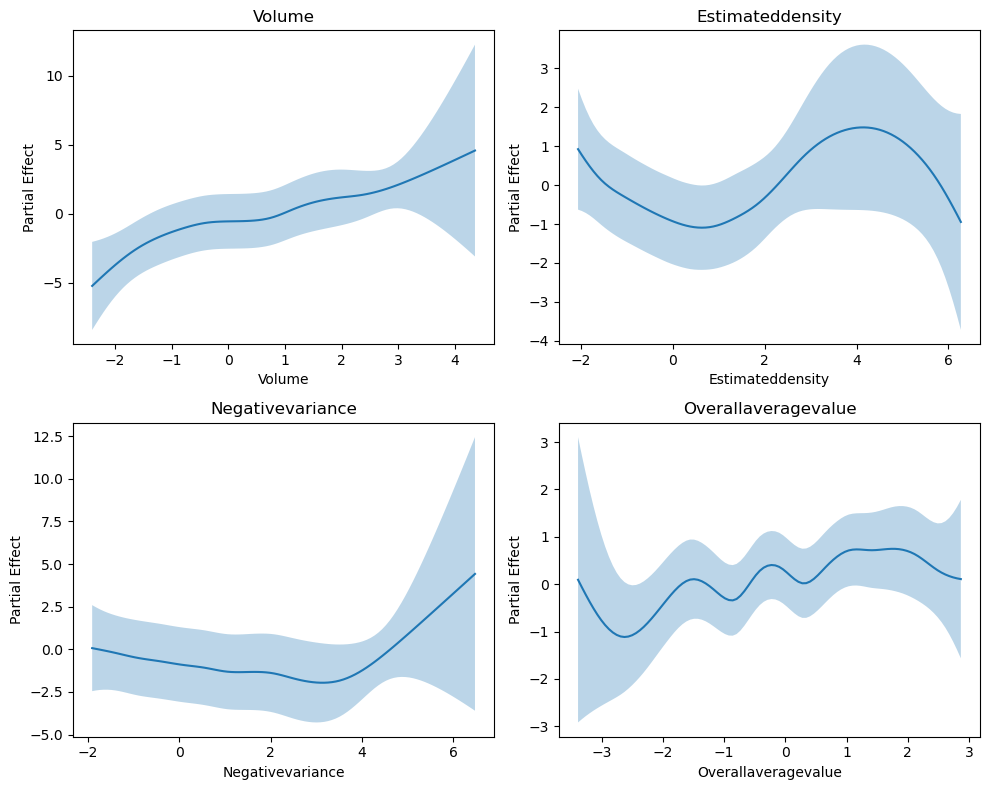

In [149]:
from pygam import LogisticGAM, s

# Features
features = [
    'Volume',
    'Estimateddensity',
    'Negativevariance',
    'Overallaveragevalue'
]

# Training data
X_train = pfas_train[features].astype(float).to_numpy()
y_train = pfas_train['class'].astype(int).to_numpy()

# Fit GAM
gam_pfas = LogisticGAM(
    s(0) + s(1) + s(2) + s(3)
).fit(X_train, y_train)


# Predictions
X_test = pfas_test[features].astype(float).to_numpy()
gam_preds = gam_pfas.predict(X_test)

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = axs.flatten()

for i, feature in enumerate(features):

    XX = gam_pfas.generate_X_grid(term=i)

    pdep, confi = gam_pfas.partial_dependence(
        term=i,
        X=XX,
        width=0.95
    )

    axs[i].plot(
        XX[:, i],
        pdep
    )

    axs[i].fill_between(
        XX[:, i],
        confi[:, 0],
        confi[:, 1],
        alpha=0.3
    )

    axs[i].set_title(feature)
    axs[i].set_xlabel(feature)
    axs[i].set_ylabel("Partial Effect")

plt.tight_layout()
plt.show()

# Stacked Models

Stacked model ROC AUC: 0.8062


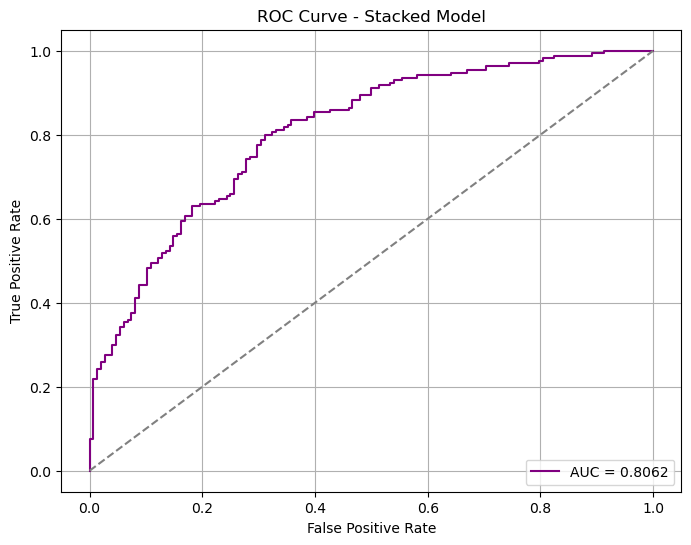

In [109]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

# Get model predictions (all should be probabilities for the positive class)

# XGBoost predictions (already from .predict)
xgboost_preds = xg_preds

# Random Forest probability predictions
rf_preds = rf_model.predict_proba(X_test)[:, 1]

# SVM probability predictions
svm_preds = svm_model.predict_proba(X_test)[:, 1]

# Stack predictions into a new feature set
stacked_data = pd.DataFrame({
    'xgboost': xgboost_preds,
    'random_forest': rf_preds,
    'svm': svm_preds
})

# Train logistic regression as meta-model (stacked learner)
meta_model = LogisticRegression()
meta_model.fit(stacked_data, y_test)

# Predict using the meta-model
stacked_preds = meta_model.predict_proba(stacked_data)[:, 1]

# Evaluate with ROC AUC
auc_value = roc_auc_score(y_test, stacked_preds)
print(f"Stacked model ROC AUC: {auc_value:.4f}")

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, stacked_preds)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_value:.4f}', color='purple')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Stacked Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [111]:
from sklearn.metrics import confusion_matrix, f1_score, matthews_corrcoef

# Convert predicted probabilities to binary class labels
stacked_binary_preds = (stacked_preds > 0.5).astype(int)

# Create confusion matrix
conf_matrix = confusion_matrix(y_test, stacked_binary_preds)
print("Confusion Matrix:\n", conf_matrix)

# F1 score
f1 = f1_score(y_test, stacked_binary_preds)
print("F1 Score:", round(f1, 4))

# MCC (Matthews Correlation Coefficient)
mcc = matthews_corrcoef(y_test, stacked_binary_preds)
print("MCC:", round(mcc, 4))

Confusion Matrix:
 [[103  45]
 [ 38 132]]
F1 Score: 0.7608
MCC: 0.4743


# Hierarchical clustering with feature importance

C:\Users\noahm\AppData\Local\Temp\ipykernel_16480\181526565.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')


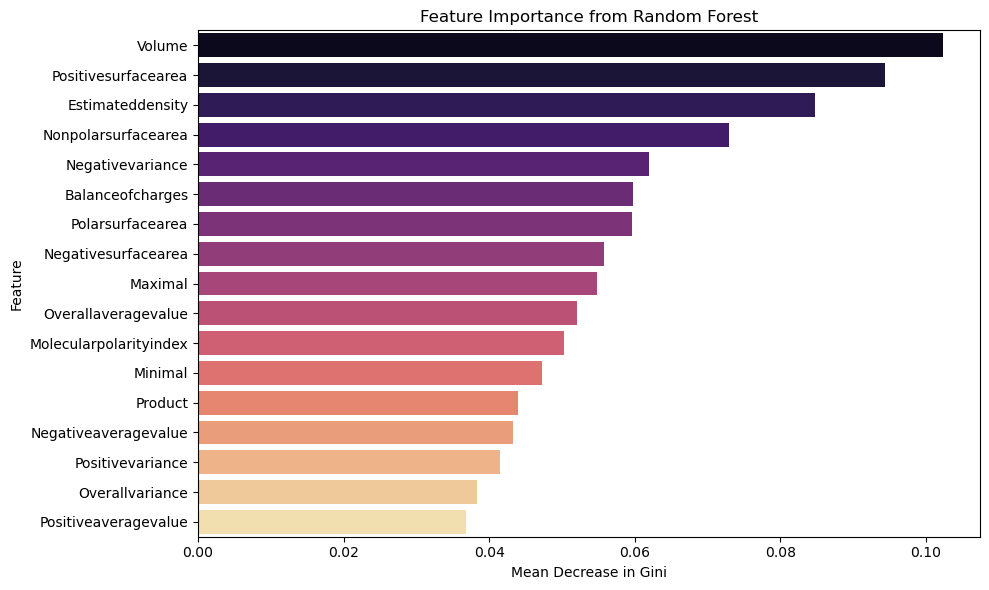

In [113]:
# Rebuild X_train using the training data used for rf_model
X_rf = pfas_train.drop(columns='class')  # drop target column
importances = rf_model.feature_importances_

# Build importance DataFrame using matching column names
importance_df = pd.DataFrame({
    'Feature': X_rf.columns,
    'Importance': importances
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')
plt.title('Feature Importance from Random Forest')
plt.xlabel('Mean Decrease in Gini')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

C:\Users\noahm\AppData\Local\Temp\ipykernel_16480\2355720859.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=balanced_data, x='cluster', y='Positivesurfacearea', palette='Set2')


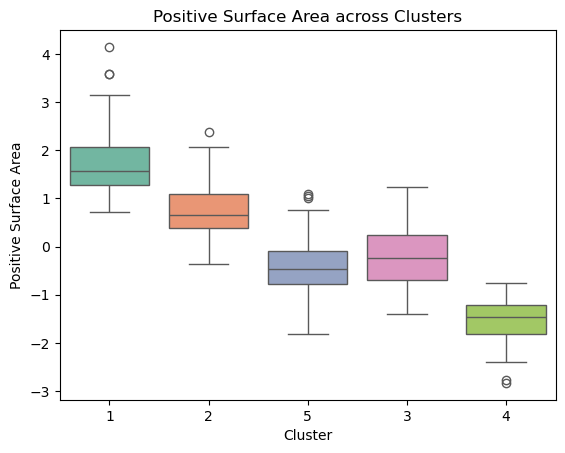

  cluster    Volume  Positivesurfacearea  Estimateddensity  \
0       1  1.803147             1.731740         -1.041197   
1       2  0.638408             0.745190         -0.514000   
2       3 -0.083180            -0.227263          0.292093   
3       4 -1.393279            -1.526547          1.372247   
4       5 -0.558500            -0.446184          0.016586   

   Nonpolarsurfacearea  Negativevariance  
0             1.703240         -0.112778  
1             0.123751          0.664926  
2             0.438520         -0.752741  
3            -0.859852         -0.788795  
4            -0.757073          0.382568  


In [121]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import fcluster

# Suppose 'importance_df' is your sorted DataFrame with feature importance
top_features = importance_df['Feature'].iloc[:5].tolist()

# Select these top features from your full dataset (balanced_data assumed to be a pandas DataFrame)
X_top = balanced_data[top_features]

# Calculate the pairwise distance matrix (Euclidean by default)
distance_matrix = pdist(X_top.values)

# Perform hierarchical clustering using Ward's method
hclust_model = linkage(distance_matrix, method='ward')

# Cut the tree into 5 clusters
k = 5
clusters = fcluster(hclust_model, k, criterion='maxclust')

# Attach clusters back to the original DataFrame
balanced_data['cluster'] = clusters.astype(str)  # as categorical/string

# Boxplot of 'Positivesurfacearea' by cluster
sns.boxplot(data=balanced_data, x='cluster', y='Positivesurfacearea', palette='Set2')
plt.title("Positive Surface Area across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Positive Surface Area")
plt.show()

# Summarize cluster means for top features
cluster_summary = balanced_data.groupby('cluster')[top_features].mean().reset_index()

print(cluster_summary)

  cluster  total  active  active_rate
0       1     84      71     0.845238
1       2    283     160     0.565371
2       3    290     159     0.548276
4       5    314     125     0.398089
3       4     88      13     0.147727


C:\Users\noahm\AppData\Local\Temp\ipykernel_16480\3596501944.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_summary, x='cluster', y='active_rate', palette='Set2')


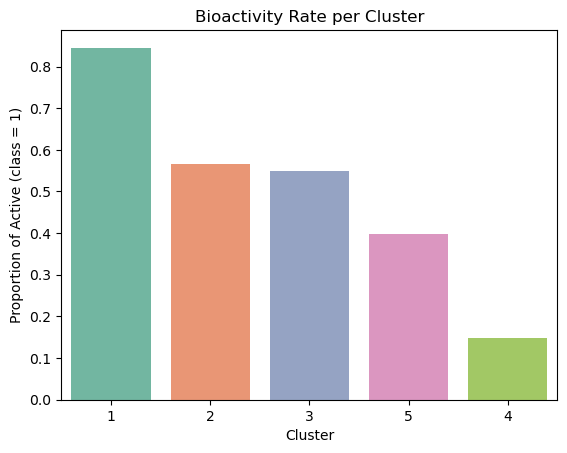

In [123]:
# Calculate cluster summary with counts and active rates
cluster_summary = (
    balanced_data.groupby('cluster')
    .agg(
        total=('class', 'size'),
        active=('class', lambda x: (x == 1).sum()),
        active_rate=('class', lambda x: (x == 1).mean())
    )
    .reset_index()
    .sort_values(by='active_rate', ascending=False)
)

print(cluster_summary)

# Plotting the bioactivity rate per cluster
sns.barplot(data=cluster_summary, x='cluster', y='active_rate', palette='Set2')
plt.title('Bioactivity Rate per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proportion of Active (class = 1)')
plt.show()

In [125]:
descriptor_summary = (
    balanced_data.groupby('cluster')
    .agg(
        ActiveRate=('class', lambda x: (x == 1).mean()),
        Estimateddensity=('Estimateddensity', 'mean'),
        Positivesurfacearea=('Positivesurfacearea', 'mean'),
        Volume=('Volume', 'mean')
    )
    .reset_index()
)

print(descriptor_summary)

  cluster  ActiveRate  Estimateddensity  Positivesurfacearea    Volume
0       1    0.845238         -1.041197             1.731740  1.803147
1       2    0.565371         -0.514000             0.745190  0.638408
2       3    0.548276          0.292093            -0.227263 -0.083180
3       4    0.147727          1.372247            -1.526547 -1.393279
4       5    0.398089          0.016586            -0.446184 -0.558500


C:\Users\noahm\AppData\Local\Temp\ipykernel_16480\1308669796.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=balanced_data, x='cluster', y='Estimateddensity', palette='Set2')


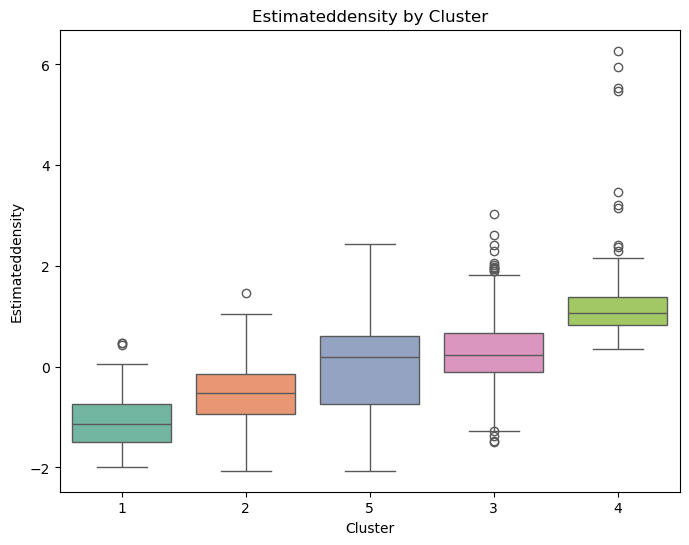

In [127]:
# Estimateddensity by Cluster
plt.figure(figsize=(8, 6))
sns.boxplot(data=balanced_data, x='cluster', y='Estimateddensity', palette='Set2')
plt.title('Estimateddensity by Cluster')
plt.ylabel('Estimateddensity')
plt.xlabel('Cluster')
plt.show()

C:\Users\noahm\AppData\Local\Temp\ipykernel_16480\2815196775.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=balanced_data, x='cluster', y='Positivesurfacearea', palette='Set2')


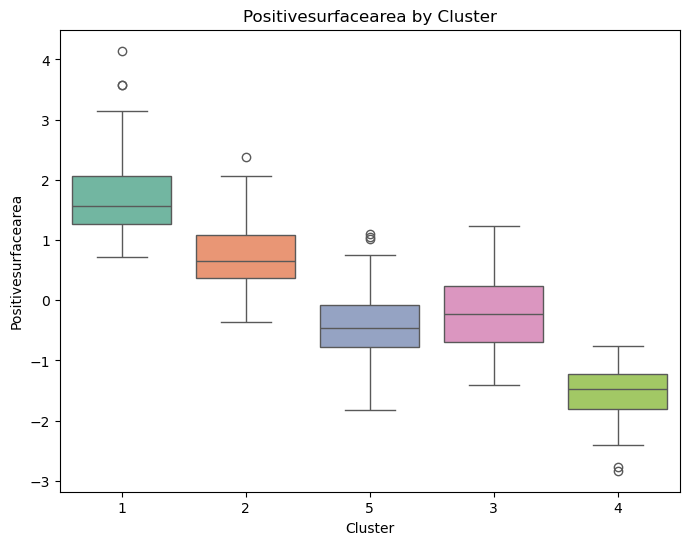

In [129]:
# Positivesurfacearea by Cluster
plt.figure(figsize=(8, 6))
sns.boxplot(data=balanced_data, x='cluster', y='Positivesurfacearea', palette='Set2')
plt.title('Positivesurfacearea by Cluster')
plt.ylabel('Positivesurfacearea')
plt.xlabel('Cluster')
plt.show()

C:\Users\noahm\AppData\Local\Temp\ipykernel_16480\500052357.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=balanced_data, x='cluster', y='Volume', palette='Set2')


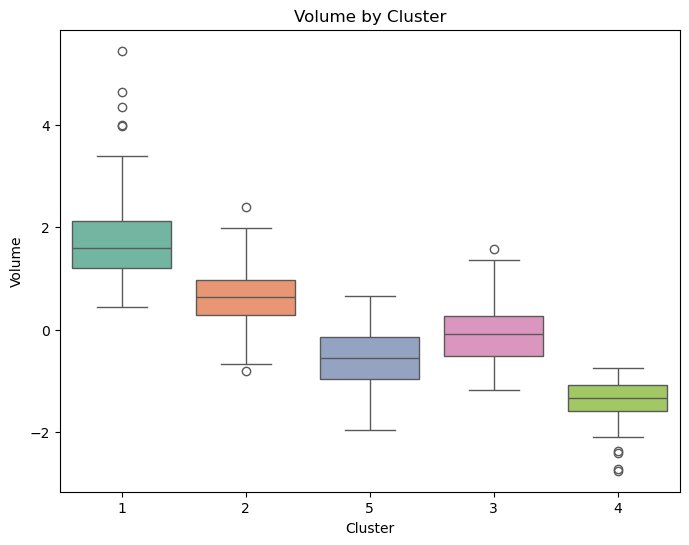

In [131]:
# Volume by Cluster
plt.figure(figsize=(8, 6))
sns.boxplot(data=balanced_data, x='cluster', y='Volume', palette='Set2')
plt.title('Volume by Cluster')
plt.ylabel('Volume')
plt.xlabel('Cluster')
plt.show()

# ROC-AUC

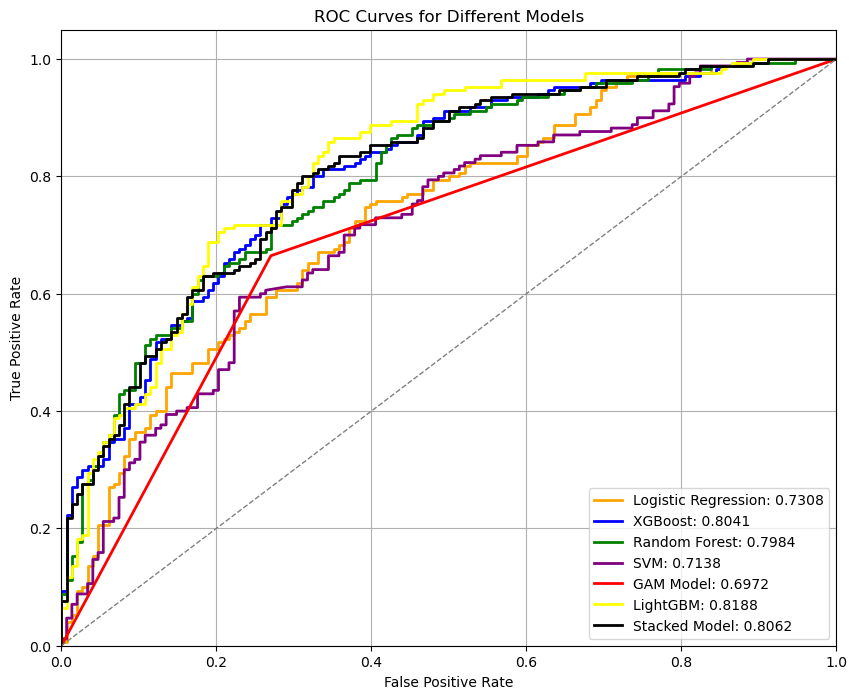

In [185]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

roc_data = {
    "Logistic Regression": (y_test, lg_preds),
    "XGBoost": (y_test, xg_preds),
    "Random Forest": (y_test, rf_probs),
    "SVM": (y_test, pred_svm_probs),
    "GAM Model": (y_test, gam_preds),
    "LightGBM": (y_test, lt_gbm_pred),
    "Stacked Model": (y_test, stacked_preds)
}

plt.figure(figsize=(10, 8))

colors = {
    "Logistic Regression": "orange",
    "XGBoost": "blue",
    "Random Forest": "green",
    "SVM": "purple",
    "GAM Model": "red",
    "LightGBM": "yellow",
    "Stacked Model": "black"
}

for model_name, (true_labels, pred_scores) in roc_data.items():
    fpr, tpr, _ = roc_curve(true_labels, pred_scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[model_name], lw=2, label=f"{model_name}: {roc_auc:.4f}")

plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Different Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()